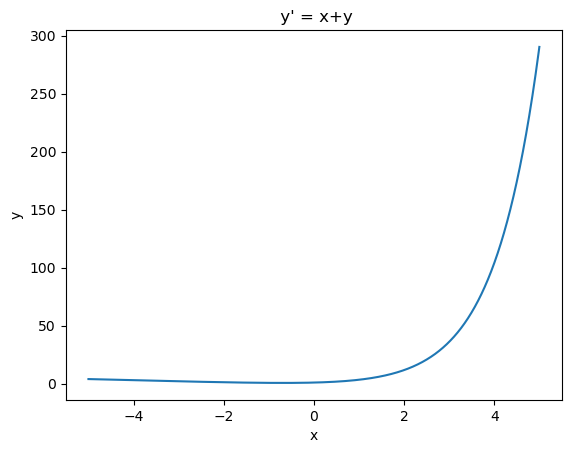

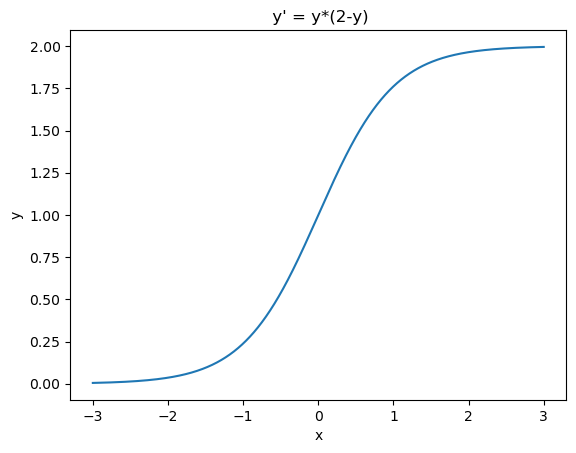

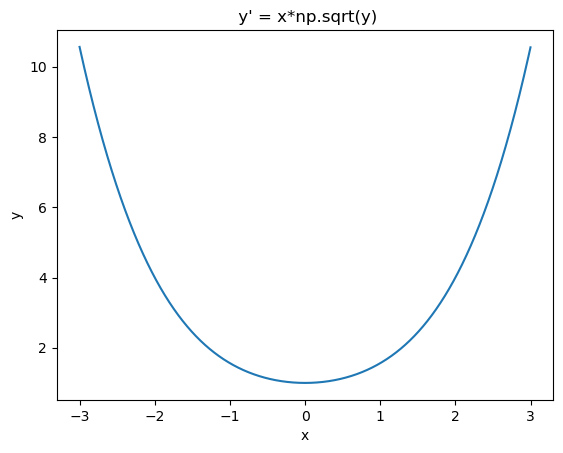

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as inte

def picard(formula, x0, y0, xstart, xend, iteration):
# this function runs the picard algorithm and plot the result
# xtart, xend: the range of x-values you want to plot
# iteration: the number of iterations you want to run, recommended at least 10 but not more than 25.
    
    ## first step of the iteration
    xrange = np.arange(xstart, xend, (xend-xstart)/5000, dtype=float) # the points of x-value that we are going to plot
                                                                    # dtype=float makes sure it's decimal and not integer
    solution = np.full(len(xrange), y0, dtype=float) # first step the solution is just the constant function y=y0
    step = 0 
    ind = np.where(np.abs(xrange-x0) == np.min(np.abs(xrange-x0)))[0][0] # the index of x in the array xrange that is closest to the value x0
                                                                # technically x0 may not be in xrange, so we integrate from xrange[ind] instead of x0 
    
    ## run the loop until step reaches the number of iteration:
    while (step < iteration):
        step += 1
        for k in range(0,len(xrange)):
            if (ind<=k):
                y = solution[ind:k+1]
                x = xrange[ind:k+1]
                solution[k] = y0 + inte.simpson(eval(formula),x=x) # the function eval() turn a string text into mathematical formula.
            else:
                y = solution[k:ind+1]
                x = xrange[k:ind+1]
                solution[k] = y0 - inte.simpson(eval(formula),x=x) # reverse the sign of the integral, 
                                                                # since we are integrating from xrange[k] to x0 instead
    ## plot the graph
    plt.figure()
    plt.plot(xrange,solution)
    plt.xlabel('x')
    plt.ylabel('y')
    title = " y' = " + str(formula)
    plt
    plt.title(title)

### Test with y'=x+y
picard('x+y',0,1,-5,5,15)    

### Test with y'=y(2-y) the logistic equation
picard('y*(2-y)',0,1,-3,3,20) 

picard('x*np.sqrt(y)',0,1,-3,3,20) 

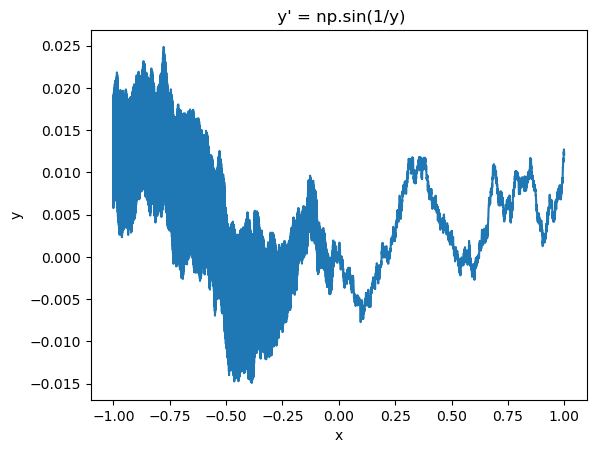

In [20]:
picard('np.sin(1/y)',0,0.001,-1,1,15) 